In [79]:
import os
import pandas as pd
from pathlib import Path

PROJECT_ROOT = next(
    candidate
    for parent in (Path.cwd(), *Path.cwd().parents)
    for candidate in (parent, parent / "Coding")
    if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir()
)
os.chdir(PROJECT_ROOT)
PROJECT_ROOT

PosixPath('/Users/tomas.p/Desktop/Survival_Analysis_Thesis/Coding')

# Activity Data Exploration

Using the OBDeleven activity logs, the goal is to characterise usage so the
survival-model design choices are grounded in the data: where to put the churn
threshold, how wide the counting-process interval should be, and which behavioural
signals are worth engineering.

Every analysis below is driven by the project classes (`DataCleaner`,
`PlottingData`, `DataSummary`) rather than ad-hoc code, so the notebook stays a
thin orchestration layer over the reusable pipeline.


## Activity-type glossary

| Variable | Short explanation |
|---|---|
| `coding` | Manual coding/adaptation of vehicle control units. |
| `scan` | Diagnostic scan for faults/DTCs across vehicle systems. |
| `clear` | Clearing/deleting detected fault codes. |
| `oca` | One-Click App: prebuilt coding/action shortcut. |
| `history_screen` | Viewing previous scans, actions, or vehicle history. |
| `live_data` | Real-time sensor/control-unit data. |
| `vehicle_lookup` | Looking up vehicle info/details from VIN or garage. |
| `native_live_data` | Brand-specific live data, richer than generic OBD2. |
| `mileage_rollback` | Mileage fraud / rollback detection check. |
| `cba_checklist` | Car Buying Assistant / inspection checklist feature. |
| `trip_tracker` | Tracking trips or driving sessions. |
| `vehicle_report` | Generated vehicle health/diagnostic report. |
| `engine_readiness` | Emissions/readiness monitor status check. |
| `car_alert` | Alerts about vehicle issues or status. |
| `battery_check` | Battery or hybrid battery condition check. |
| `maintenance_reminder` | Reminder for service or maintenance tasks. |


In [80]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path

from src.constants import paths_to_files_and_folders as const
from src.constants.columns import USER_ID_COL, VEHICLE_ID_COL, VEHICLE_END_YEAR_COL
import src.constants.variables_groupings as variables_and_groupings

from src.data_cleaning import DataCleaner
from src.plotting import PlottingData
from src.data_summary import DataSummary

## Inputs

The plotting and summary classes consume the **interim CSVs produced by
`02_data_cleaning_and_saving`**: raw (segmented, but no churn/cutoff filtering) for
distributional views, and filtered (truncated at churn) for the interval grid.
They are read with Polars because the plotting and summary methods parse the string
date columns themselves.


In [81]:
INTERIM = const.PATH_TO_INTERIM_DATA
FINAL = const.PATH_TO_FINAL_DATA
FIGURE_DIR = PROJECT_ROOT.parent / "Output" / "01_data_exploration"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PERSONAL_RAW           = INTERIM / "personal_users_raw.csv"
PROFESSIONAL_RAW       = INTERIM / "professional_users_raw.csv"
PERSONAL_FILTERED      = INTERIM / "personal_users_filtered.csv"
PROFESSIONAL_FILTERED  = INTERIM / "professional_users_filtered.csv"
MERGEED_RAW            = INTERIM / "merged_all_users_raw.csv"
PERSONAL_FEATURE_AGGREGATED = FINAL / "features_personal_14_day_intervals_new_features.csv"

personal_raw      = pl.read_csv(PERSONAL_RAW)
professional_raw  = pl.read_csv(PROFESSIONAL_RAW)
personal_filtered = pl.read_csv(PERSONAL_FILTERED)
professional_filtered = pl.read_csv(PROFESSIONAL_FILTERED)
merged_all_raw = pl.read_csv(MERGEED_RAW)

plotter = PlottingData()
summary = DataSummary()

## 1. Raw-data sanity checks

These operate on the unmerged raw files and motivate decisions made inside
`DataCleaner` (dropping rows without a `vehicle_id`, dropping ambiguous
user/vehicle duplicates, and treating a missing `vehicle_end_year` as
still-in-production).


In [82]:
activity_df = pd.read_csv(const.PATH_TO_RAW_ACTIVITY_DATA)
vehicle_df  = pd.read_csv(const.PATH_TO_RAW_VEHICLE_DATA)

# Rows without a vehicle_id cannot carry static vehicle metadata downstream
print("NaN vehicle_id rows in activity:", activity_df["vehicle_id"].isna().sum())
print("NaN vehicle_id rows in vehicle :", vehicle_df["vehicle_id"].isna().sum())

# Share of activity vehicle_ids that have no metadata row at all
present = pd.Series(activity_df["vehicle_id"].unique()).isin(vehicle_df["vehicle_id"].unique()).sum()
missing_pct = (activity_df["vehicle_id"].nunique() - present) / activity_df["vehicle_id"].nunique()
print(f"vehicle_id metadata missing: {missing_pct * 100:.2f}%")

NaN vehicle_id rows in activity: 7762
NaN vehicle_id rows in vehicle : 0
vehicle_id metadata missing: 0.00%


In [83]:
# Users whose same vehicle_id appears under conflicting metadata rows (dropped on merge)
dupe = (vehicle_df.groupby([USER_ID_COL, VEHICLE_ID_COL])[VEHICLE_ID_COL]
        .count().gt(1).groupby(level=0).any())
print("Users with duplicate vehicle metadata:", int(dupe.sum()))

# Missing end-year => model still in production. ~7.5% confirms most cars are discontinued
print(f"vehicle_end_year missing: {vehicle_df[VEHICLE_END_YEAR_COL].isna().mean() * 100:.2f}%")

# 95th percentile of unique vehicles per user — informs the quantile split criterion
print("95th pct unique vehicles/user:",
      vehicle_df.groupby(USER_ID_COL)[VEHICLE_ID_COL].nunique().quantile(0.95))

Users with duplicate vehicle metadata: 5
vehicle_end_year missing: 7.31%
95th pct unique vehicles/user: 22.0


## 2. User segmentation (personal vs professional) 

The split itself lives in `DataCleaner.filter_users_by_type` (an OR of three
criteria: effective inverse-HHI, top-4 vehicle share, and a unique-vehicle-count
quantile, each covering the others' blind spots). Here we just load the already
segmented raw files and report their sizes.


In [84]:
print("Personal users    :", personal_raw[USER_ID_COL].n_unique())
print("Professional users:", professional_raw[USER_ID_COL].n_unique())

Personal users    : 8328
Professional users: 579


## 3. Activity-type distribution

Composition of what users actually do. Run per segment to contrast personal vs
professional behaviour. Counts are at the raw-activity level (no burst collapse),
because the mix of actions is the quantity of interest.


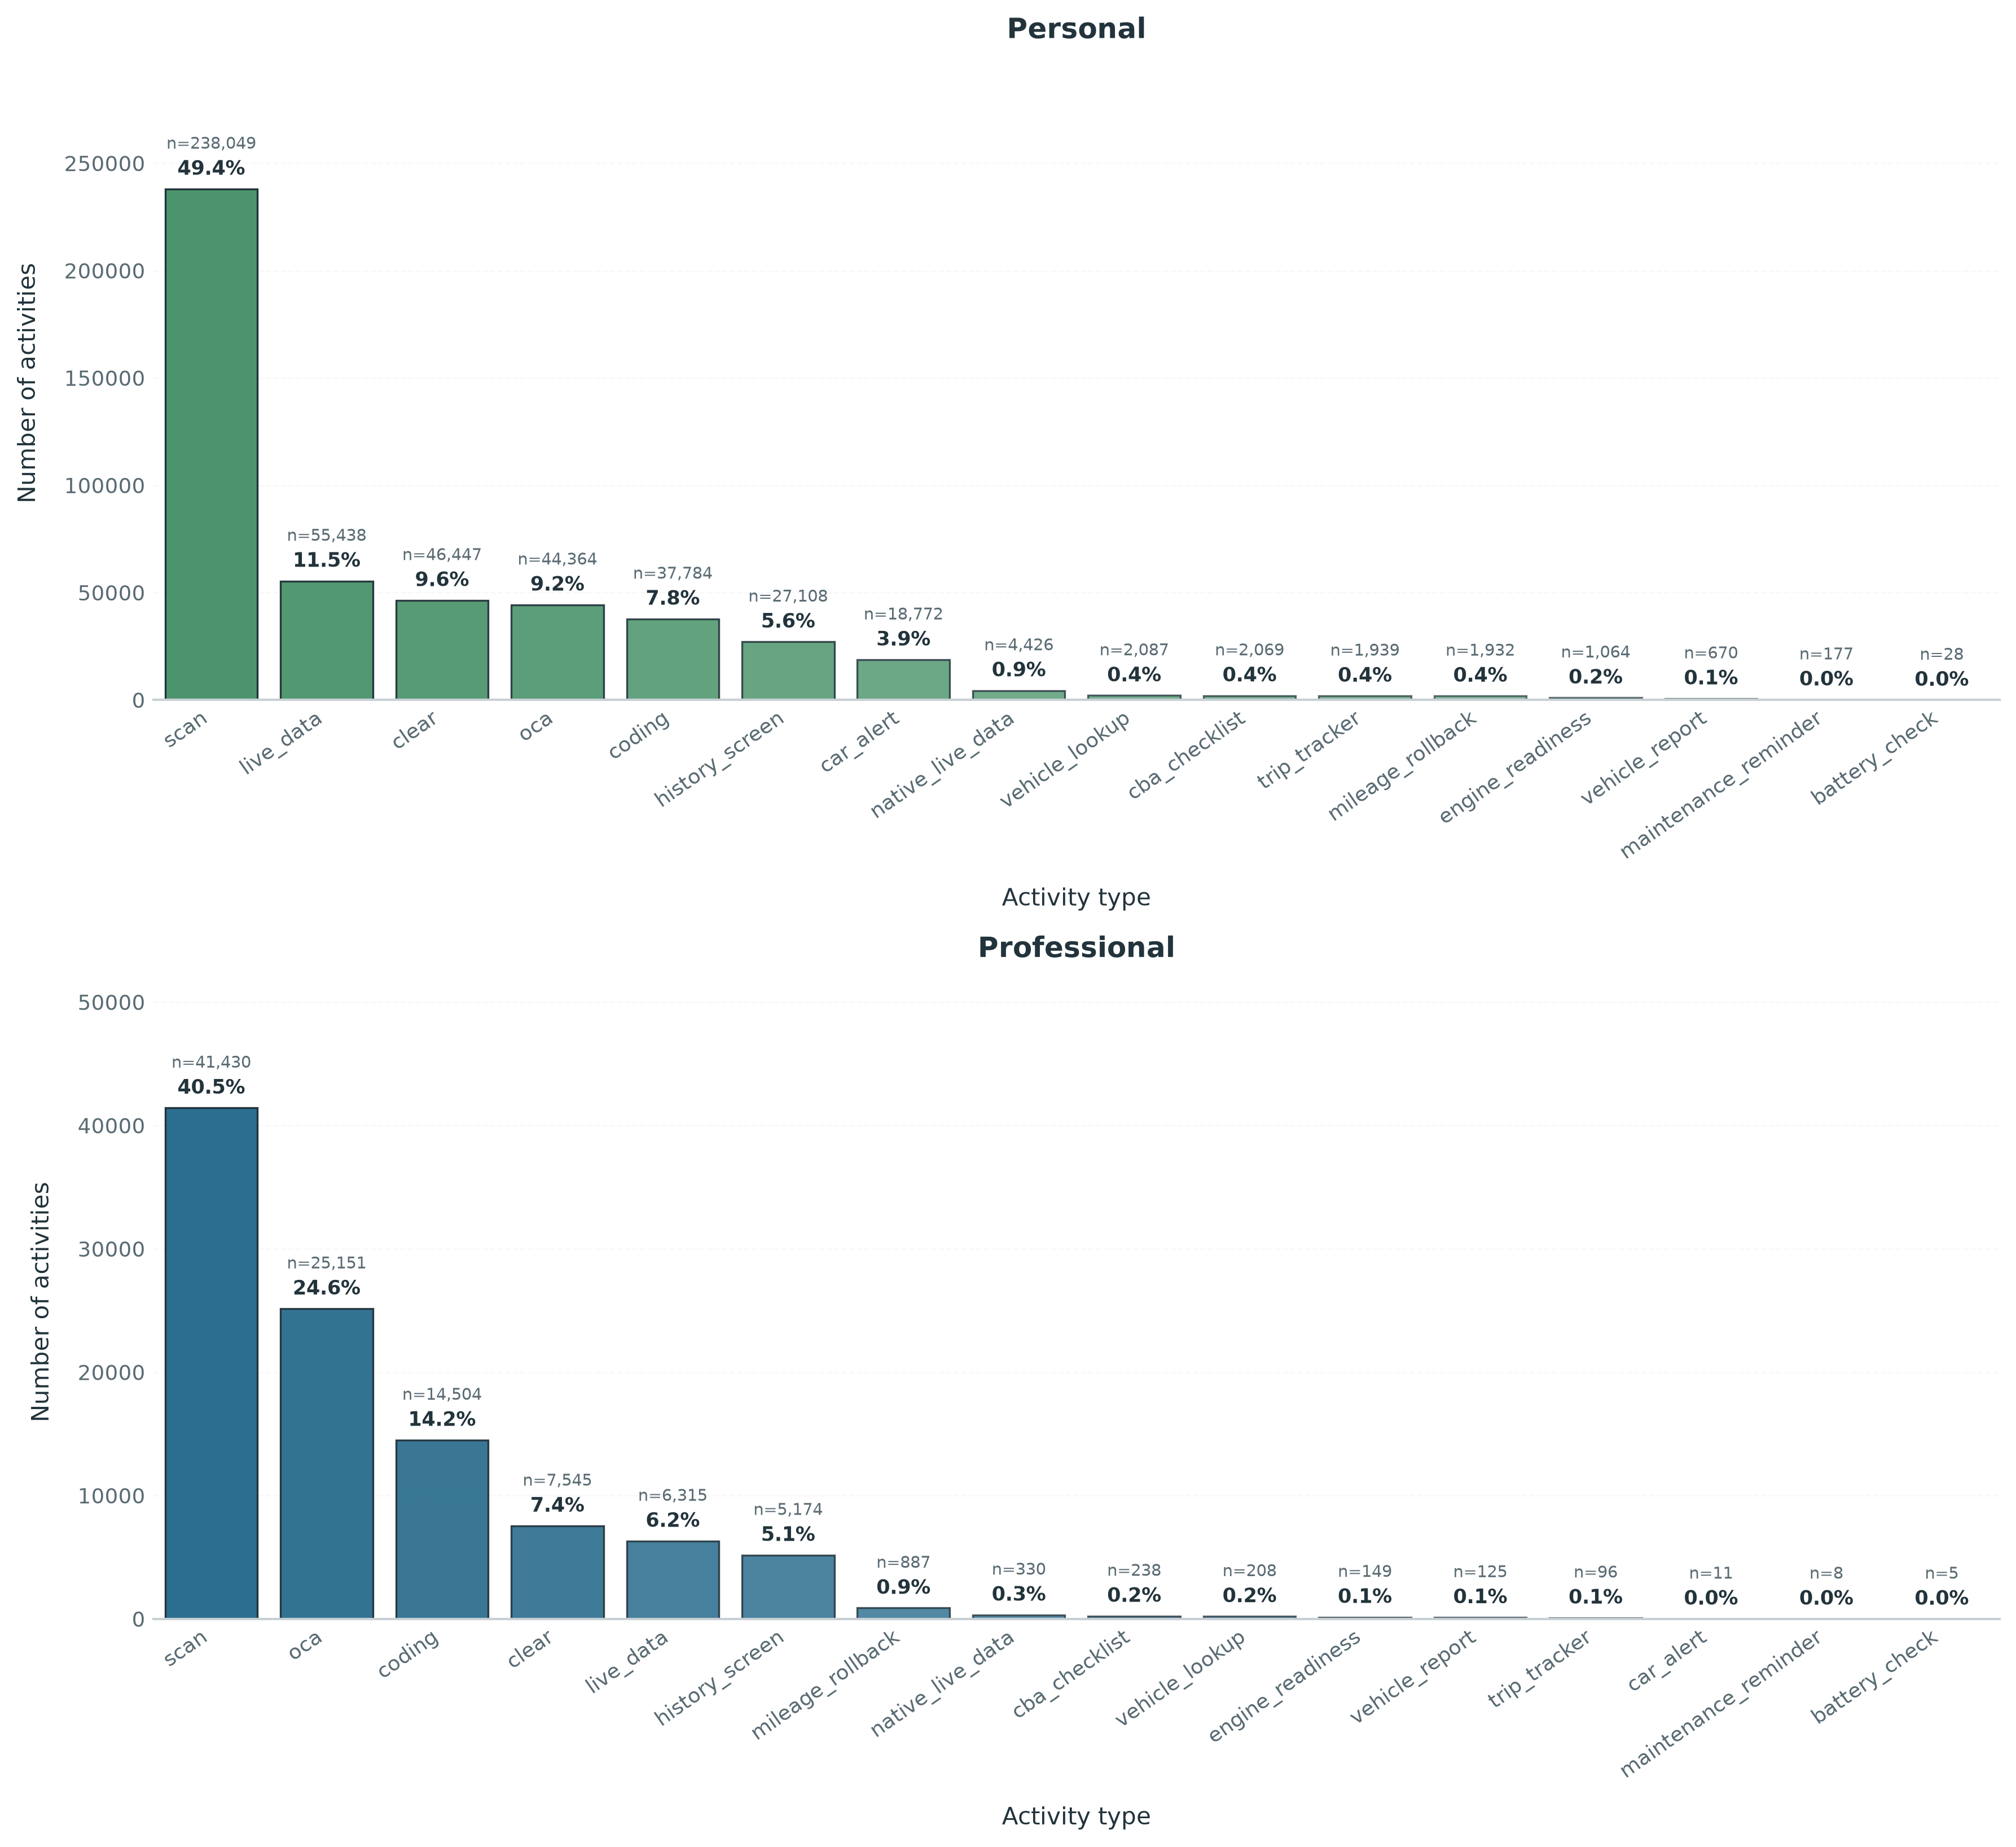

In [85]:
fig, axes = plt.subplots(2, 1, figsize=(12, 11))

plotter.return_activity_distribution_plot(personal_raw,     ax=axes[0], personal=True)
plotter.return_activity_distribution_plot(professional_raw, ax=axes[1], personal=False)

axes[0].set_title("Personal",     fontweight="bold", pad=12)
axes[1].set_title("Professional", fontweight="bold", pad=12)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_activity_type_distribution.png", bbox_inches="tight")
plt.show()

## 4. User-split validation

Each user plotted by unique-vehicle count vs top-4 vehicle share, sized by
effective HHI. This is a visual check that the split landed where intended:
personal users should cluster at low vehicle counts and high concentration,
professionals should spread toward many vehicles and lower concentration. The
diagnostics are computed on burst-filtered data, matching the classifier.


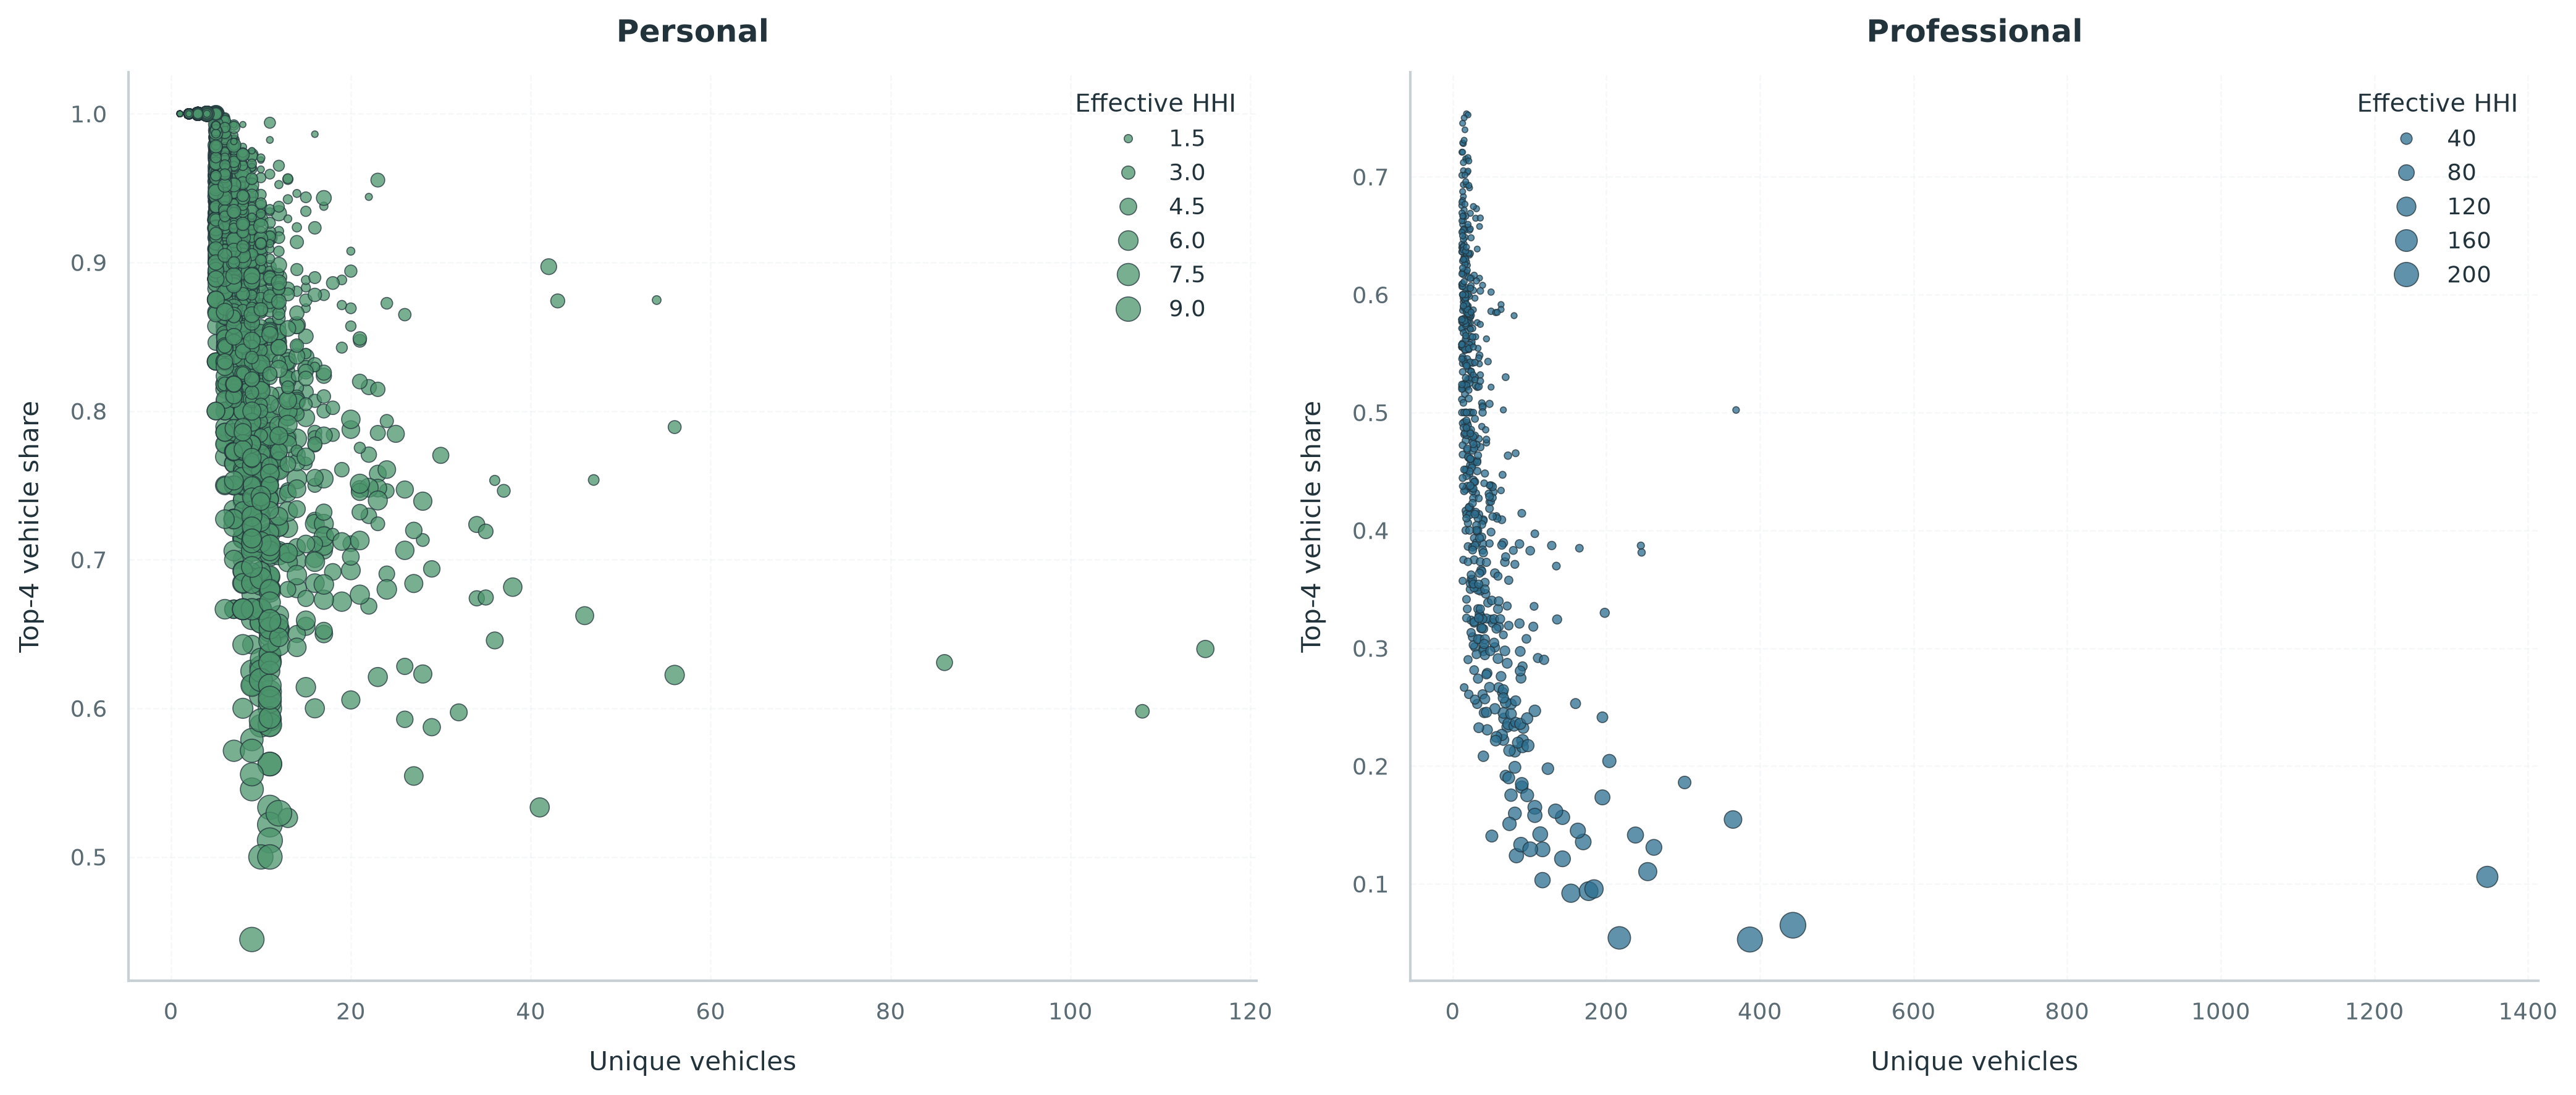

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plotter.return_user_split_plot(personal_raw,     ax=axes[0], personal=True)
plotter.return_user_split_plot(professional_raw, ax=axes[1], personal=False)

axes[0].set_title("Personal",     fontweight="bold", pad=12)
axes[1].set_title("Professional", fontweight="bold", pad=12)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_user_split_validation.png", bbox_inches="tight")
plt.show()

## 5. Inter-activity gap distribution

Days between consecutive active days — the core evidence for the churn threshold
and the interval/lookback sizes. Read on **raw** data so the long right tail is
intact; quantile lines mark the median and 95th percentile, and the x-axis is
trimmed at the 99th percentile so the tail does not flatten the visible mass.


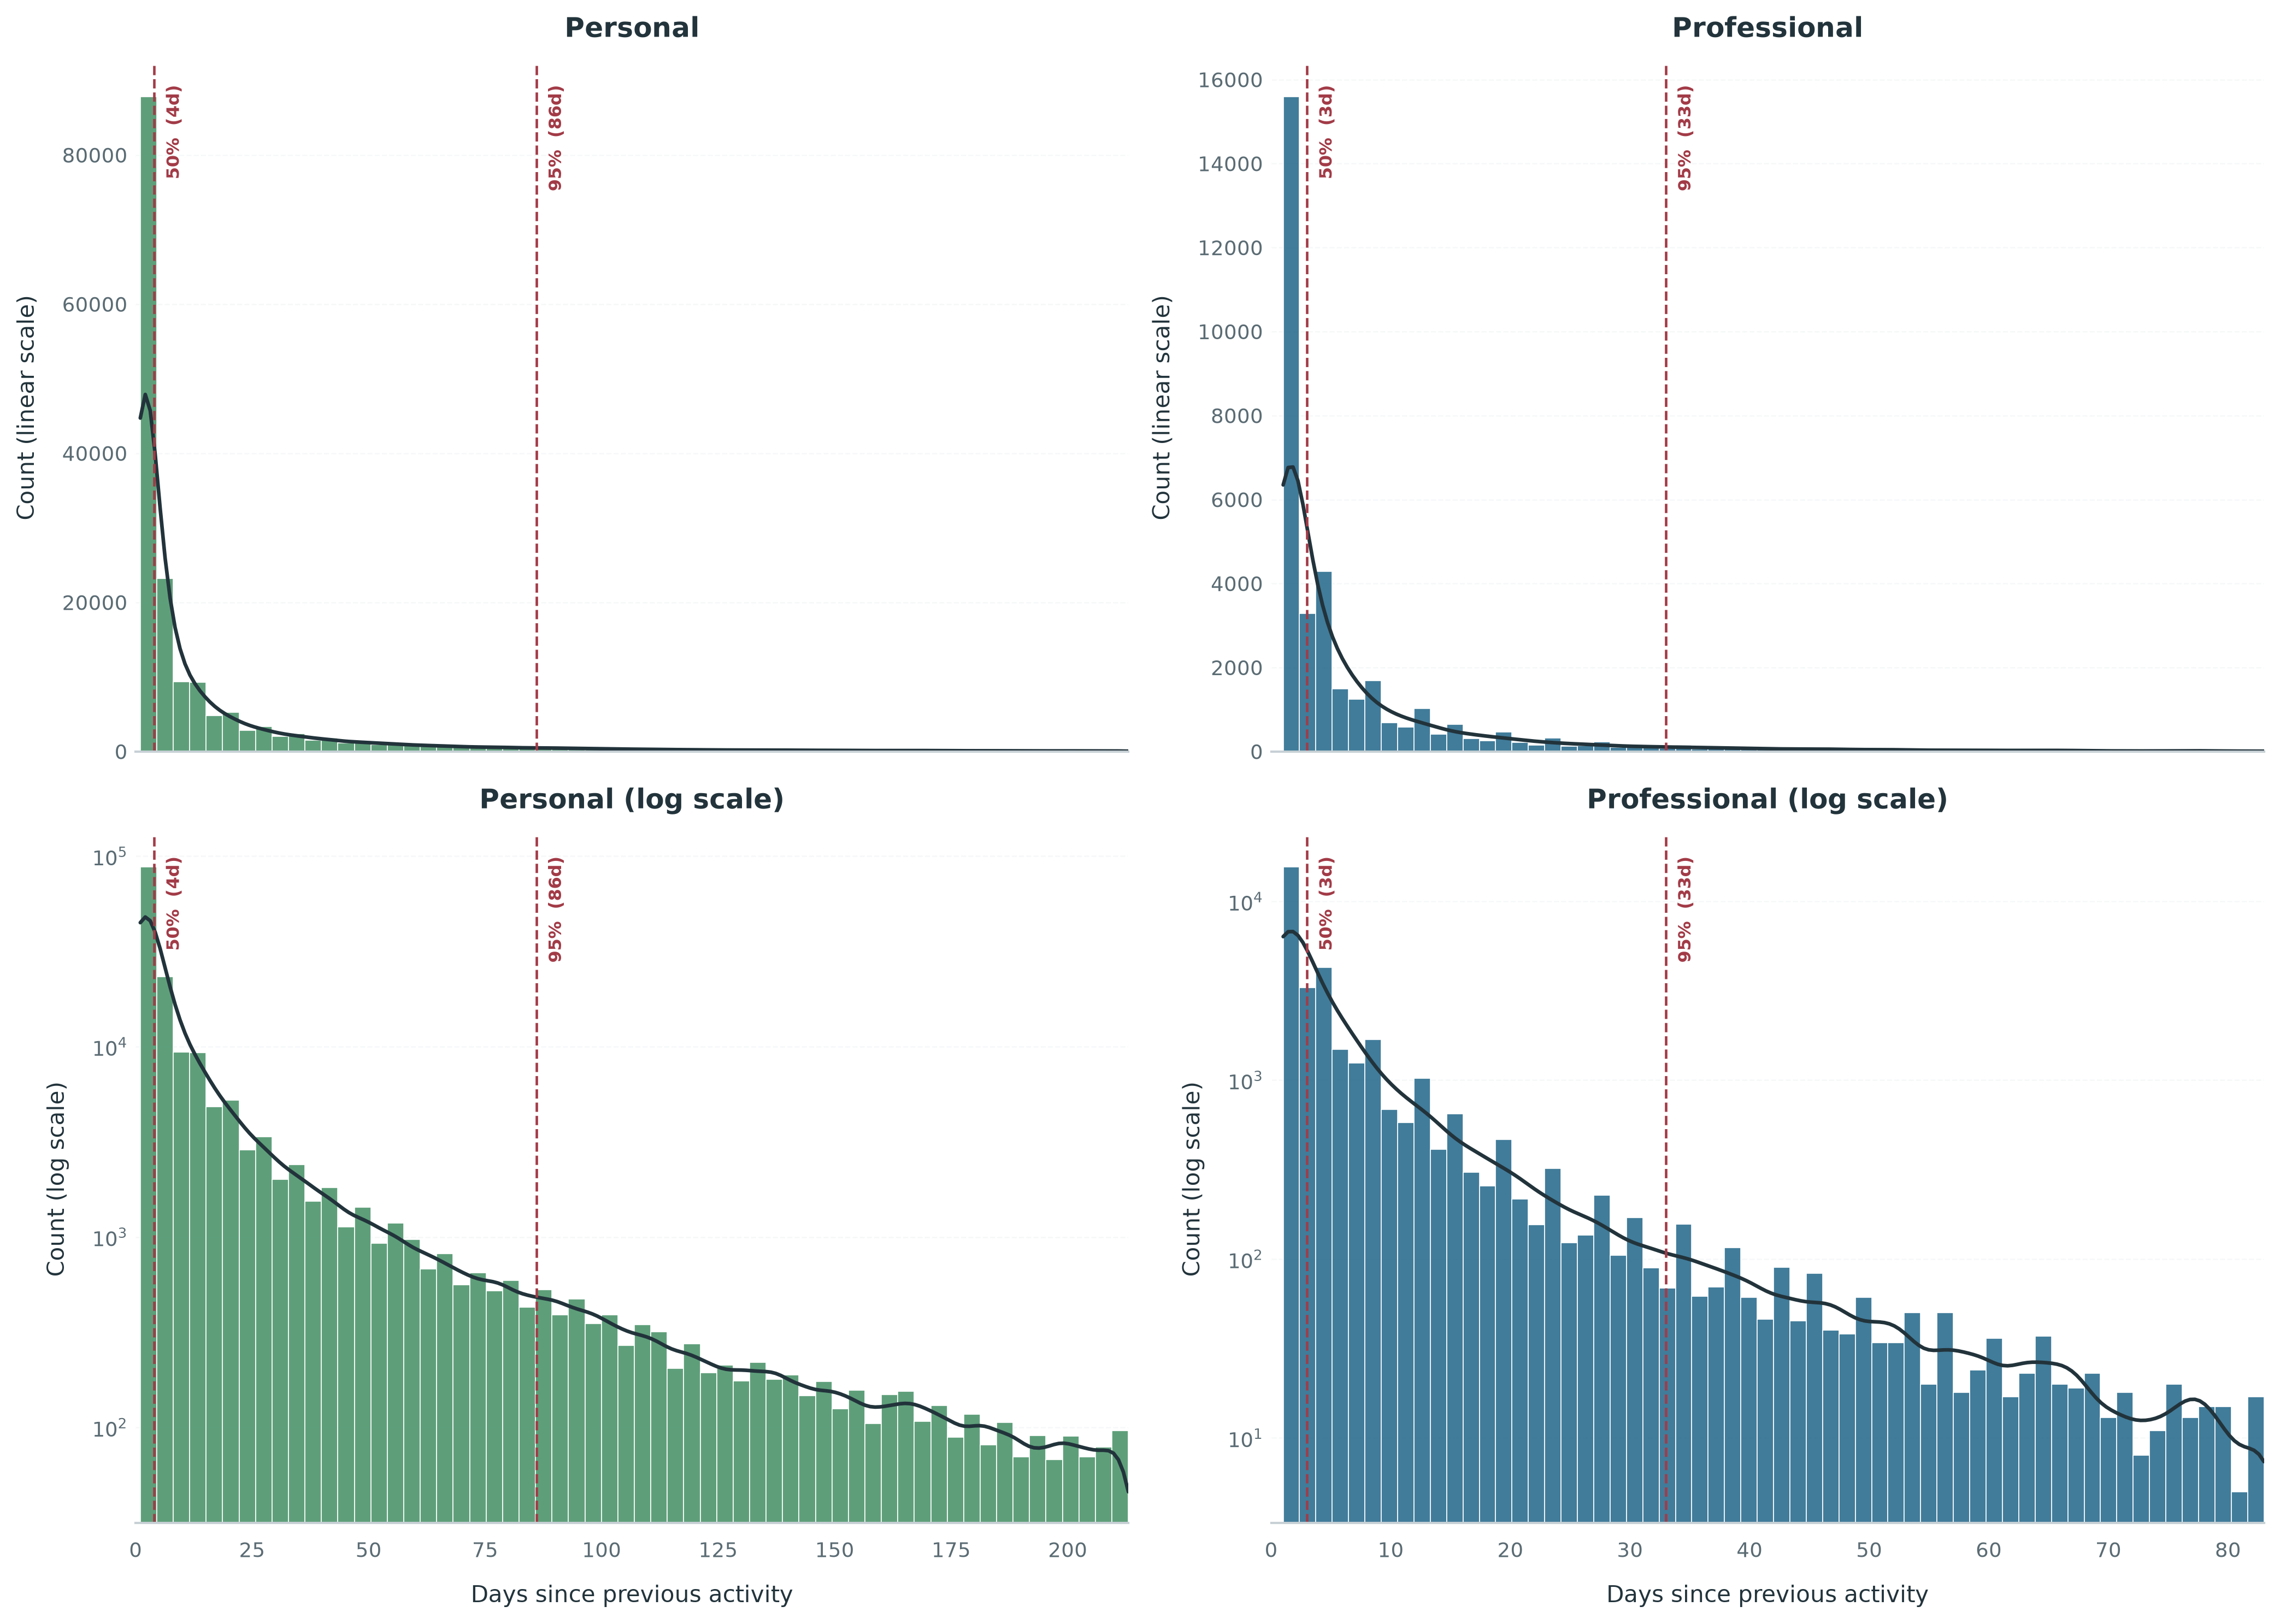

In [87]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex="col")

plotter.return_activity_gap_distribution(
    personal_raw, ax=axes[0, 0], personal=True,
    quantiles=[0.5, 0.95], quantile_boundary=0.99)
plotter.return_activity_gap_distribution(
    professional_raw, ax=axes[0, 1], personal=False,
    quantiles=[0.5, 0.95], quantile_boundary=0.99)
plotter.return_activity_gap_distribution(
    personal_raw, ax=axes[1, 0], personal=True,
    quantiles=[0.5, 0.95], quantile_boundary=0.99,
    set_y_scale_to_log=True)
plotter.return_activity_gap_distribution(
    professional_raw, ax=axes[1, 1], personal=False,
    quantiles=[0.5, 0.95], quantile_boundary=0.99,
    set_y_scale_to_log=True)

axes[0, 0].set_title("Personal",             fontweight="bold", pad=12)
axes[0, 1].set_title("Professional",         fontweight="bold", pad=12)
axes[1, 0].set_title("Personal (log scale)", fontweight="bold", pad=12)
axes[1, 1].set_title("Professional (log scale)", fontweight="bold", pad=12)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_inter_activity_gap_distribution.png", bbox_inches="tight")
plt.show()

In [88]:
print("Personal gap (days):")
print(summary.return_activity_gap_summary(personal_raw))

Personal gap (days):
            gap_days
count  172331.000000
mean       18.360069
std        41.301522
min         1.000000
25%         1.000000
50%         4.000000
75%        15.000000
90%        47.000000
95%        86.000000
99%       213.000000
max       937.000000


Gap of users after churn filtering. Required for reasoning about summarization widths and lookback intervals

In [89]:
print("Personal gap (days):")
print(summary.return_activity_gap_summary(personal_filtered))

Personal gap (days):
            gap_days
count  148728.000000
mean       13.701273
std        23.855944
min         1.000000
25%         1.000000
50%         4.000000
75%        14.000000
90%        39.000000
95%        65.650000
99%       123.000000
max       160.000000


## 6. Interval-width selection

Trades intervals-per-user against the empty-interval rate for each candidate
width. Run on the **filtered** dataset, since the grid spans each user's at-risk
window (needs `churn_adjusted_date`). 14d gives finer resolution but a higher
empty rate; 28d is coarser but cleaner. Empty intervals are not waste — under the
counting-process formulation they are explicit "no activity" observations.


In [90]:
summary.return_interval_summary(personal_filtered, interval_sizes=[14, 28, 56])

/Users/tomas.p/Desktop/Survival_Analysis_Thesis/Coding/src/data_summary.py:105: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_with_intervals = df.join_asof(
/Users/tomas.p/Desktop/Survival_Analysis_Thesis/Coding/src/data_summary.py:105: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_with_intervals = df.join_asof(
/Users/tomas.p/Desktop/Survival_Analysis_Thesis/Coding/src/data_summary.py:105: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_with_intervals = df.join_asof(


,interval_days,mean_intervals,median_intervals,p25_intervals,p75_intervals,empty_interval_rate
0,14,30.075333,27.0,21.0,37.0,0.5986
1,28,15.287667,14.0,11.0,19.0,0.4261
2,56,7.898000,7.0,6.0,10.0,0.2366


## 7. Seasonality

Activity by calendar month, peak highlighted. Read on **raw** data (truncating at
churn would drop later months and bias the seasonal shape); bursts are collapsed
so a single session counts once.


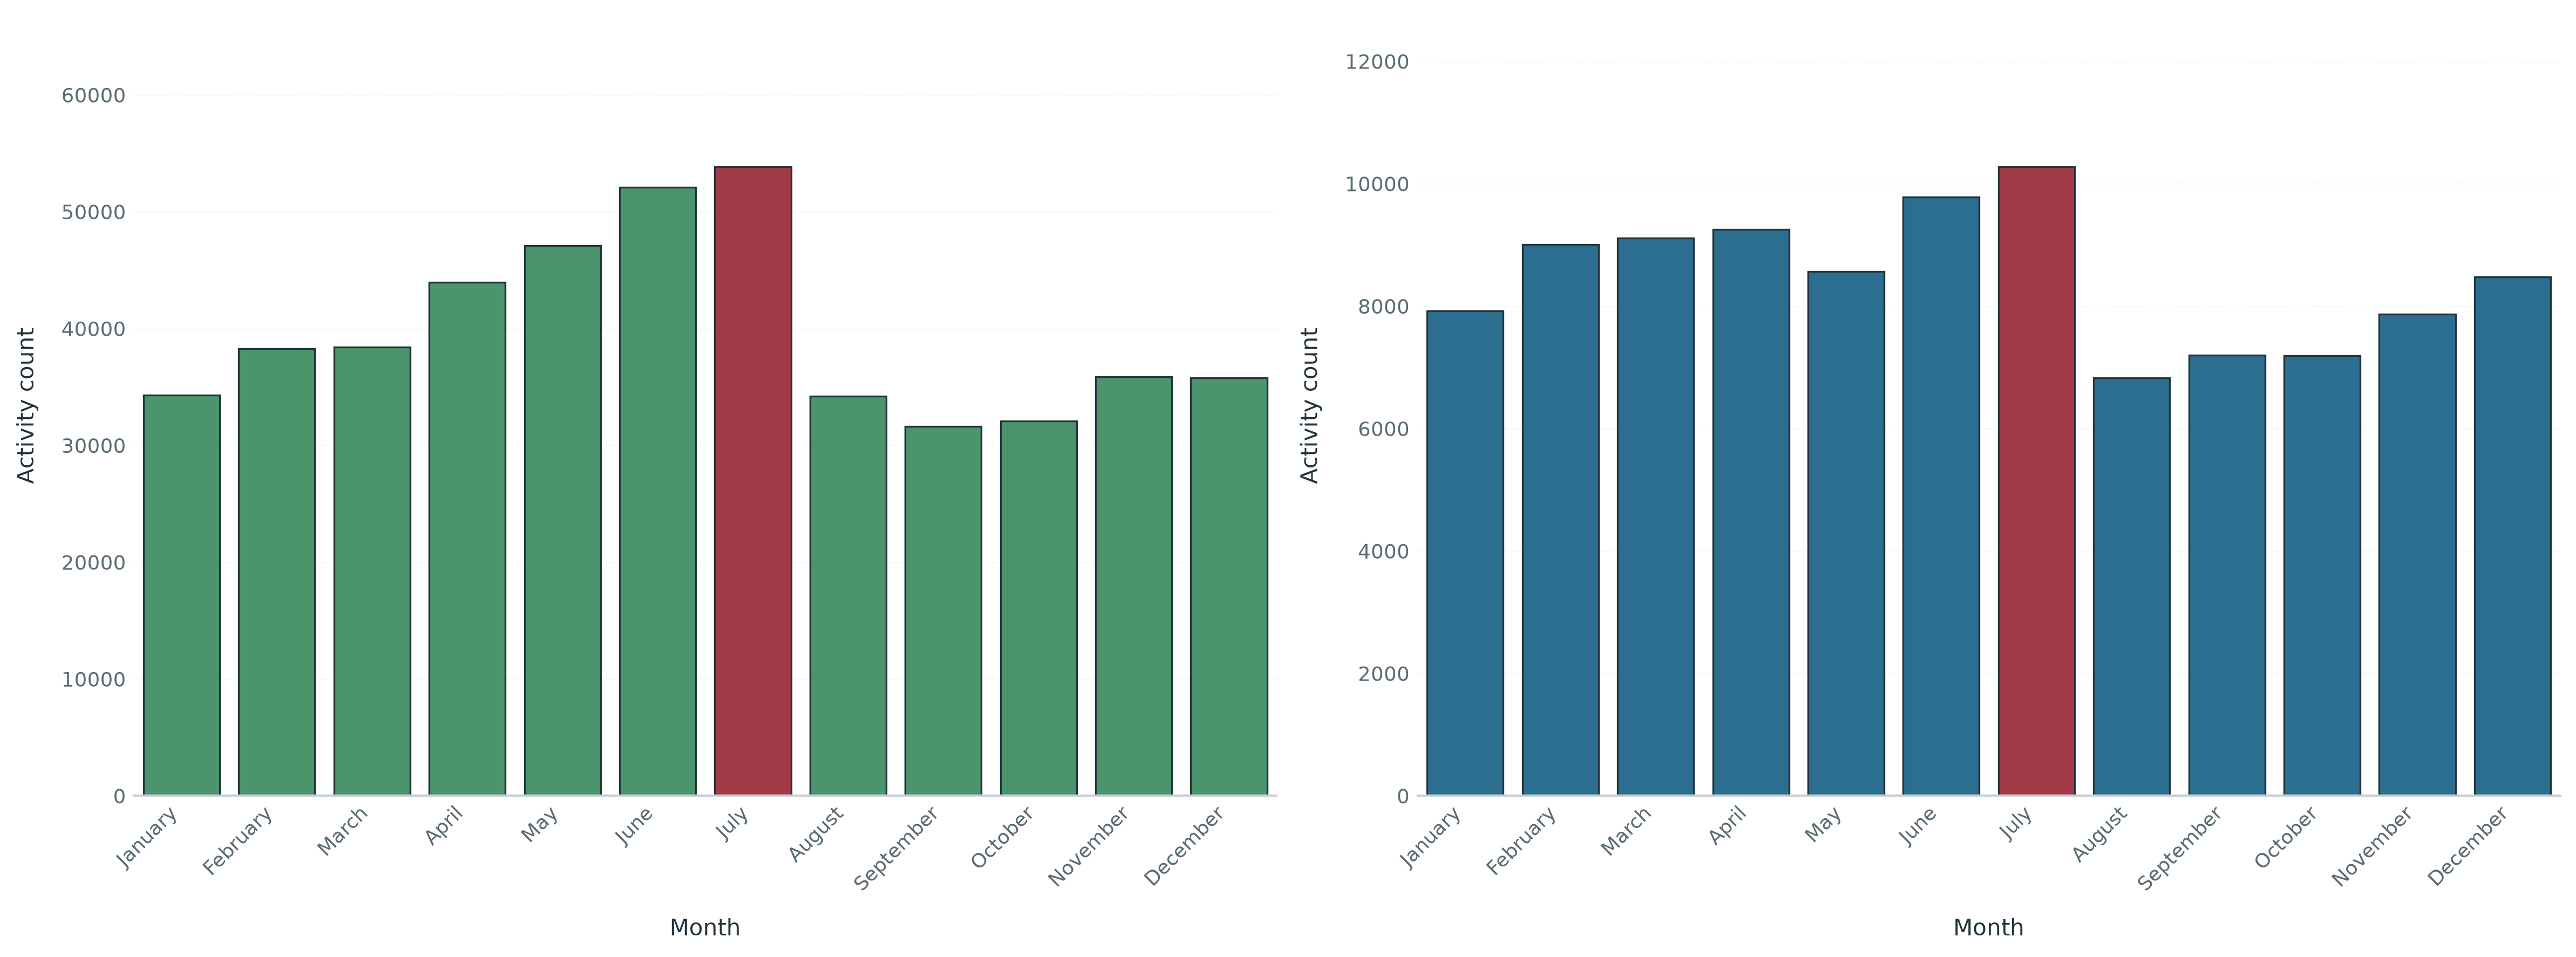

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plotter.return_seasonality_plot(personal_raw,     ax=axes[0], personal=True)
plotter.return_seasonality_plot(professional_raw, ax=axes[1], personal=False)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_seasonality.png", bbox_inches="tight")
plt.show()

## 8. Vehicle-make distribution

Make composition at the vehicle level (deduplicated by `vehicle_id`). Justifies
the make grouping and the per-make proportion features. Makes are raw here; the
`brand_group_map` collapsing (e.g. Mini into the BMW group) happens later in
feature engineering.


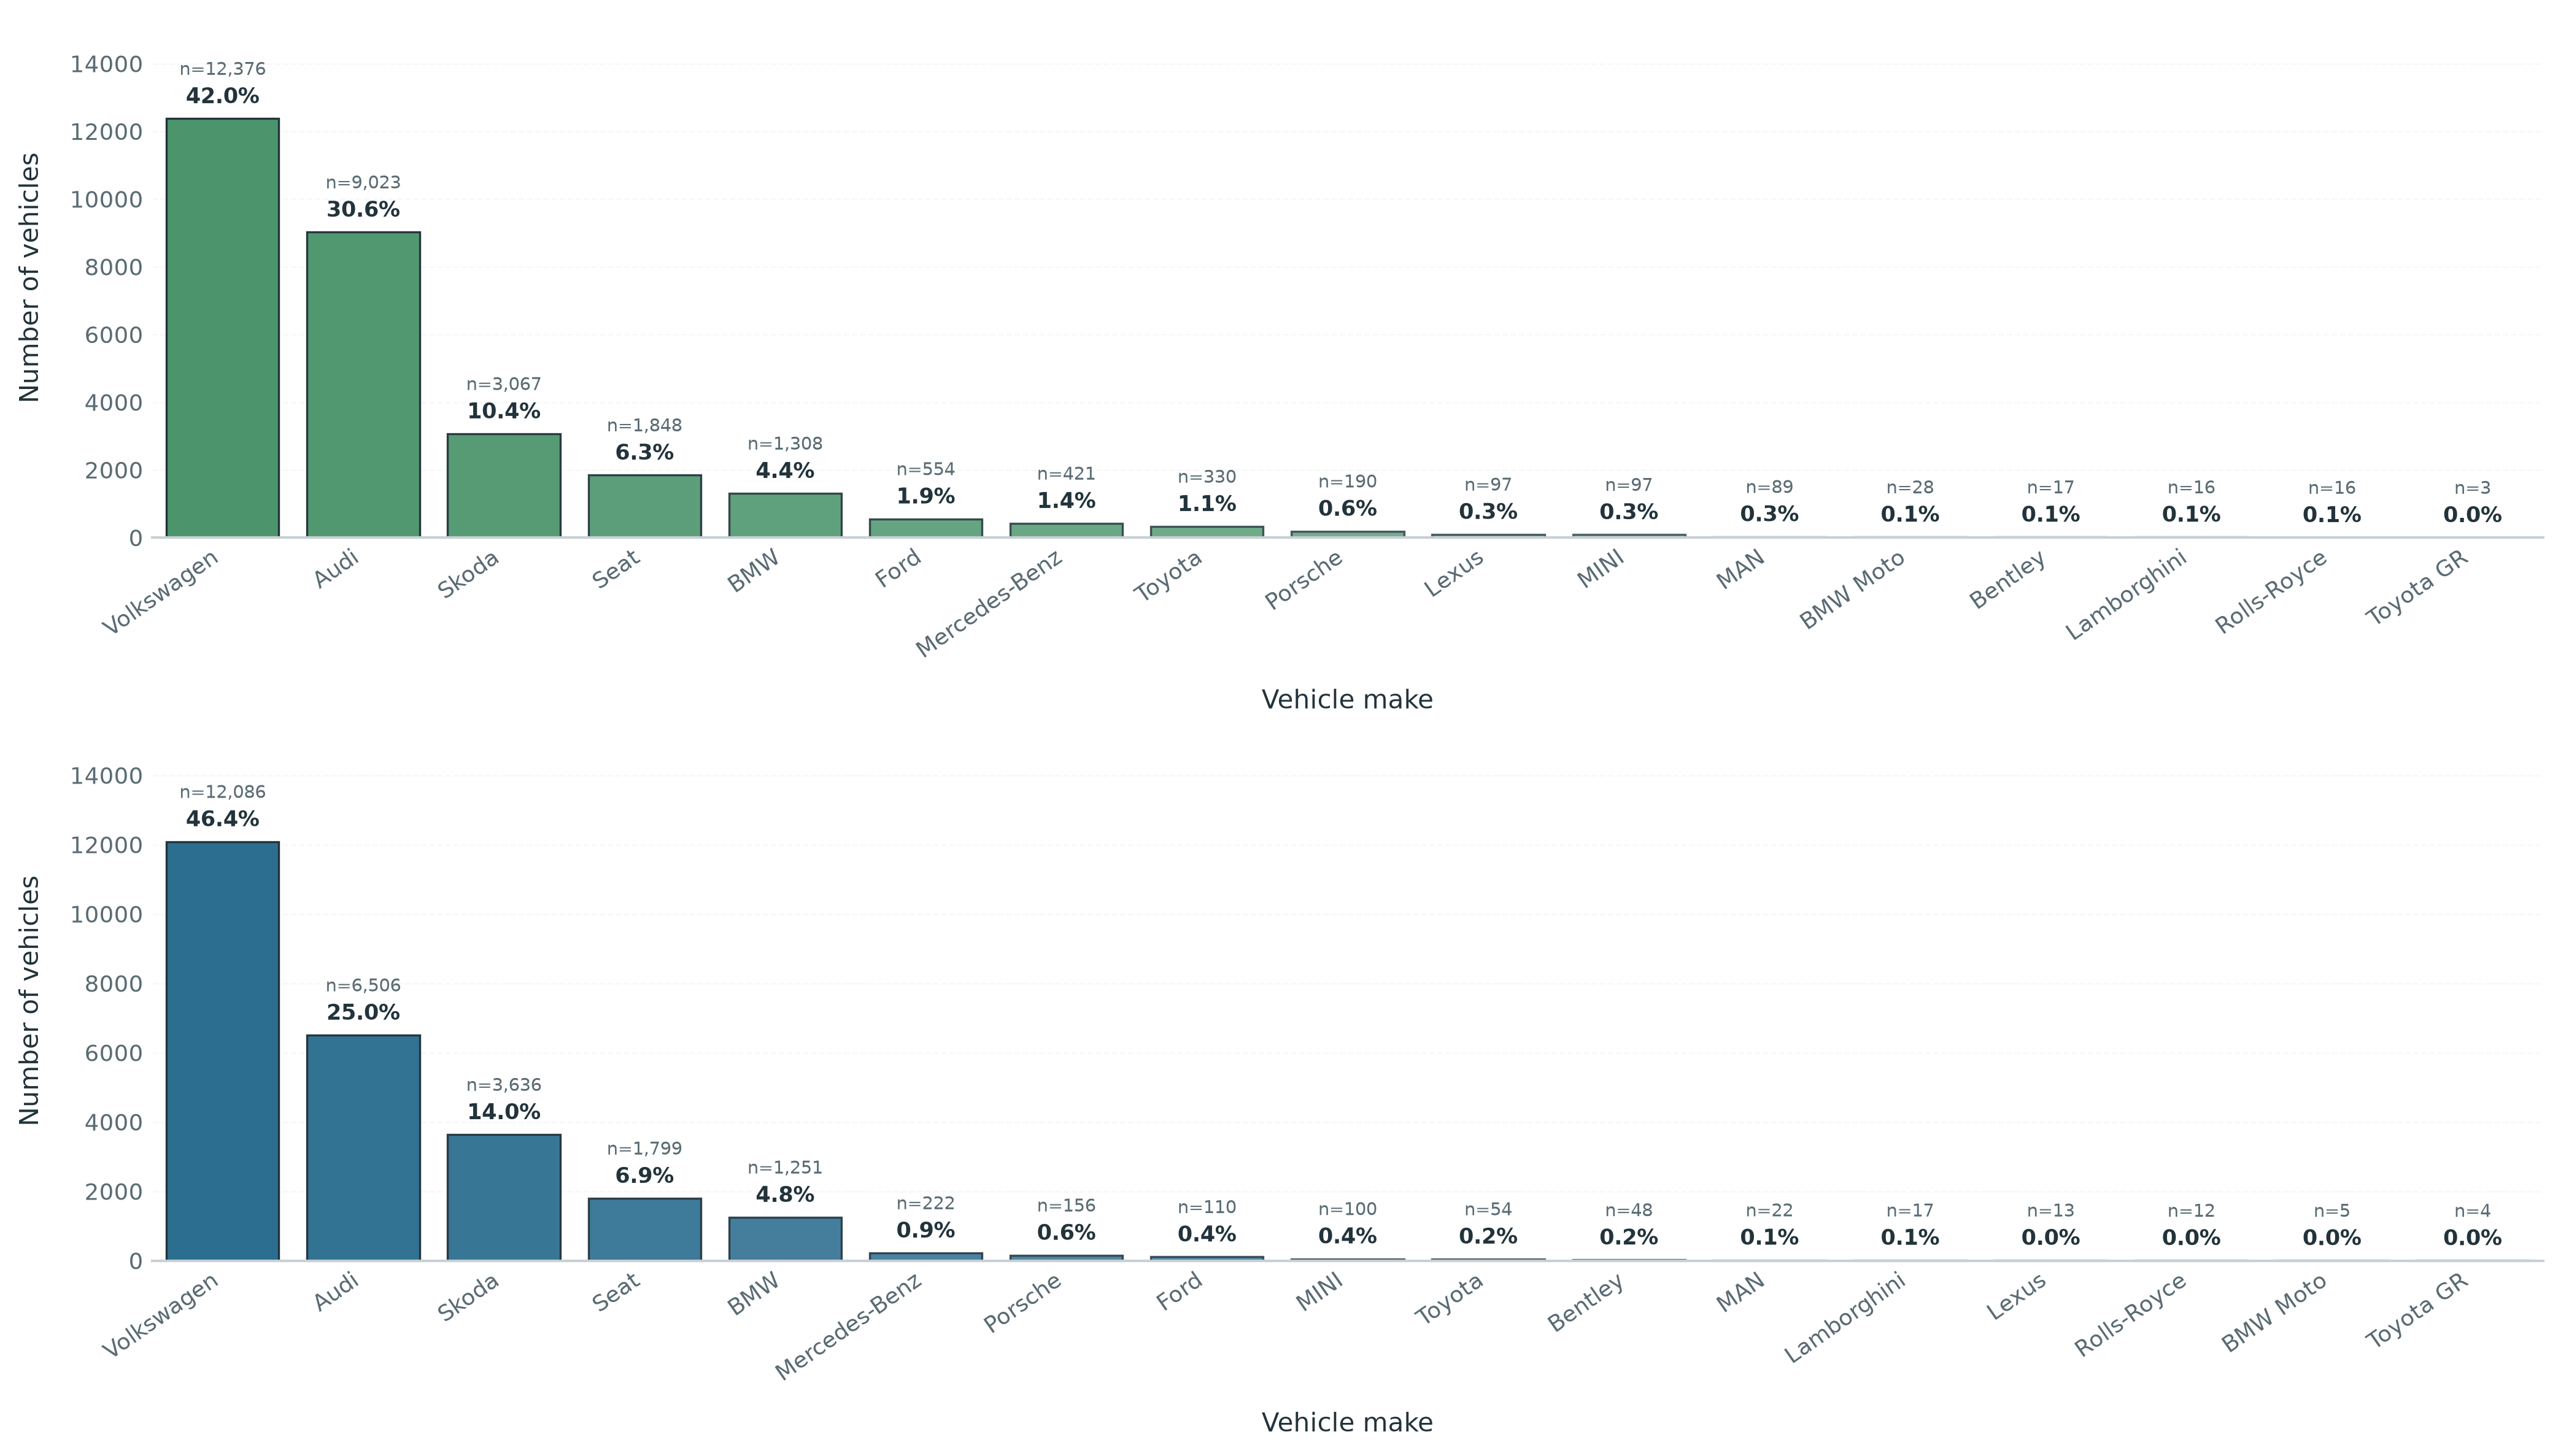

In [92]:
fig, ax = plt.subplots(2,1, figsize=(14, 8))
personal_v_plot = plotter.return_vehicle_make_distribution_plot(personal_raw, ax=ax[0], personal=True)


plotter.return_vehicle_make_distribution_plot(professional_raw, ax=ax[1],personal=False)


plt.tight_layout()
fig.savefig(FIGURE_DIR / "05_vehicle_make_by_segment.png", bbox_inches="tight")
plt.show()

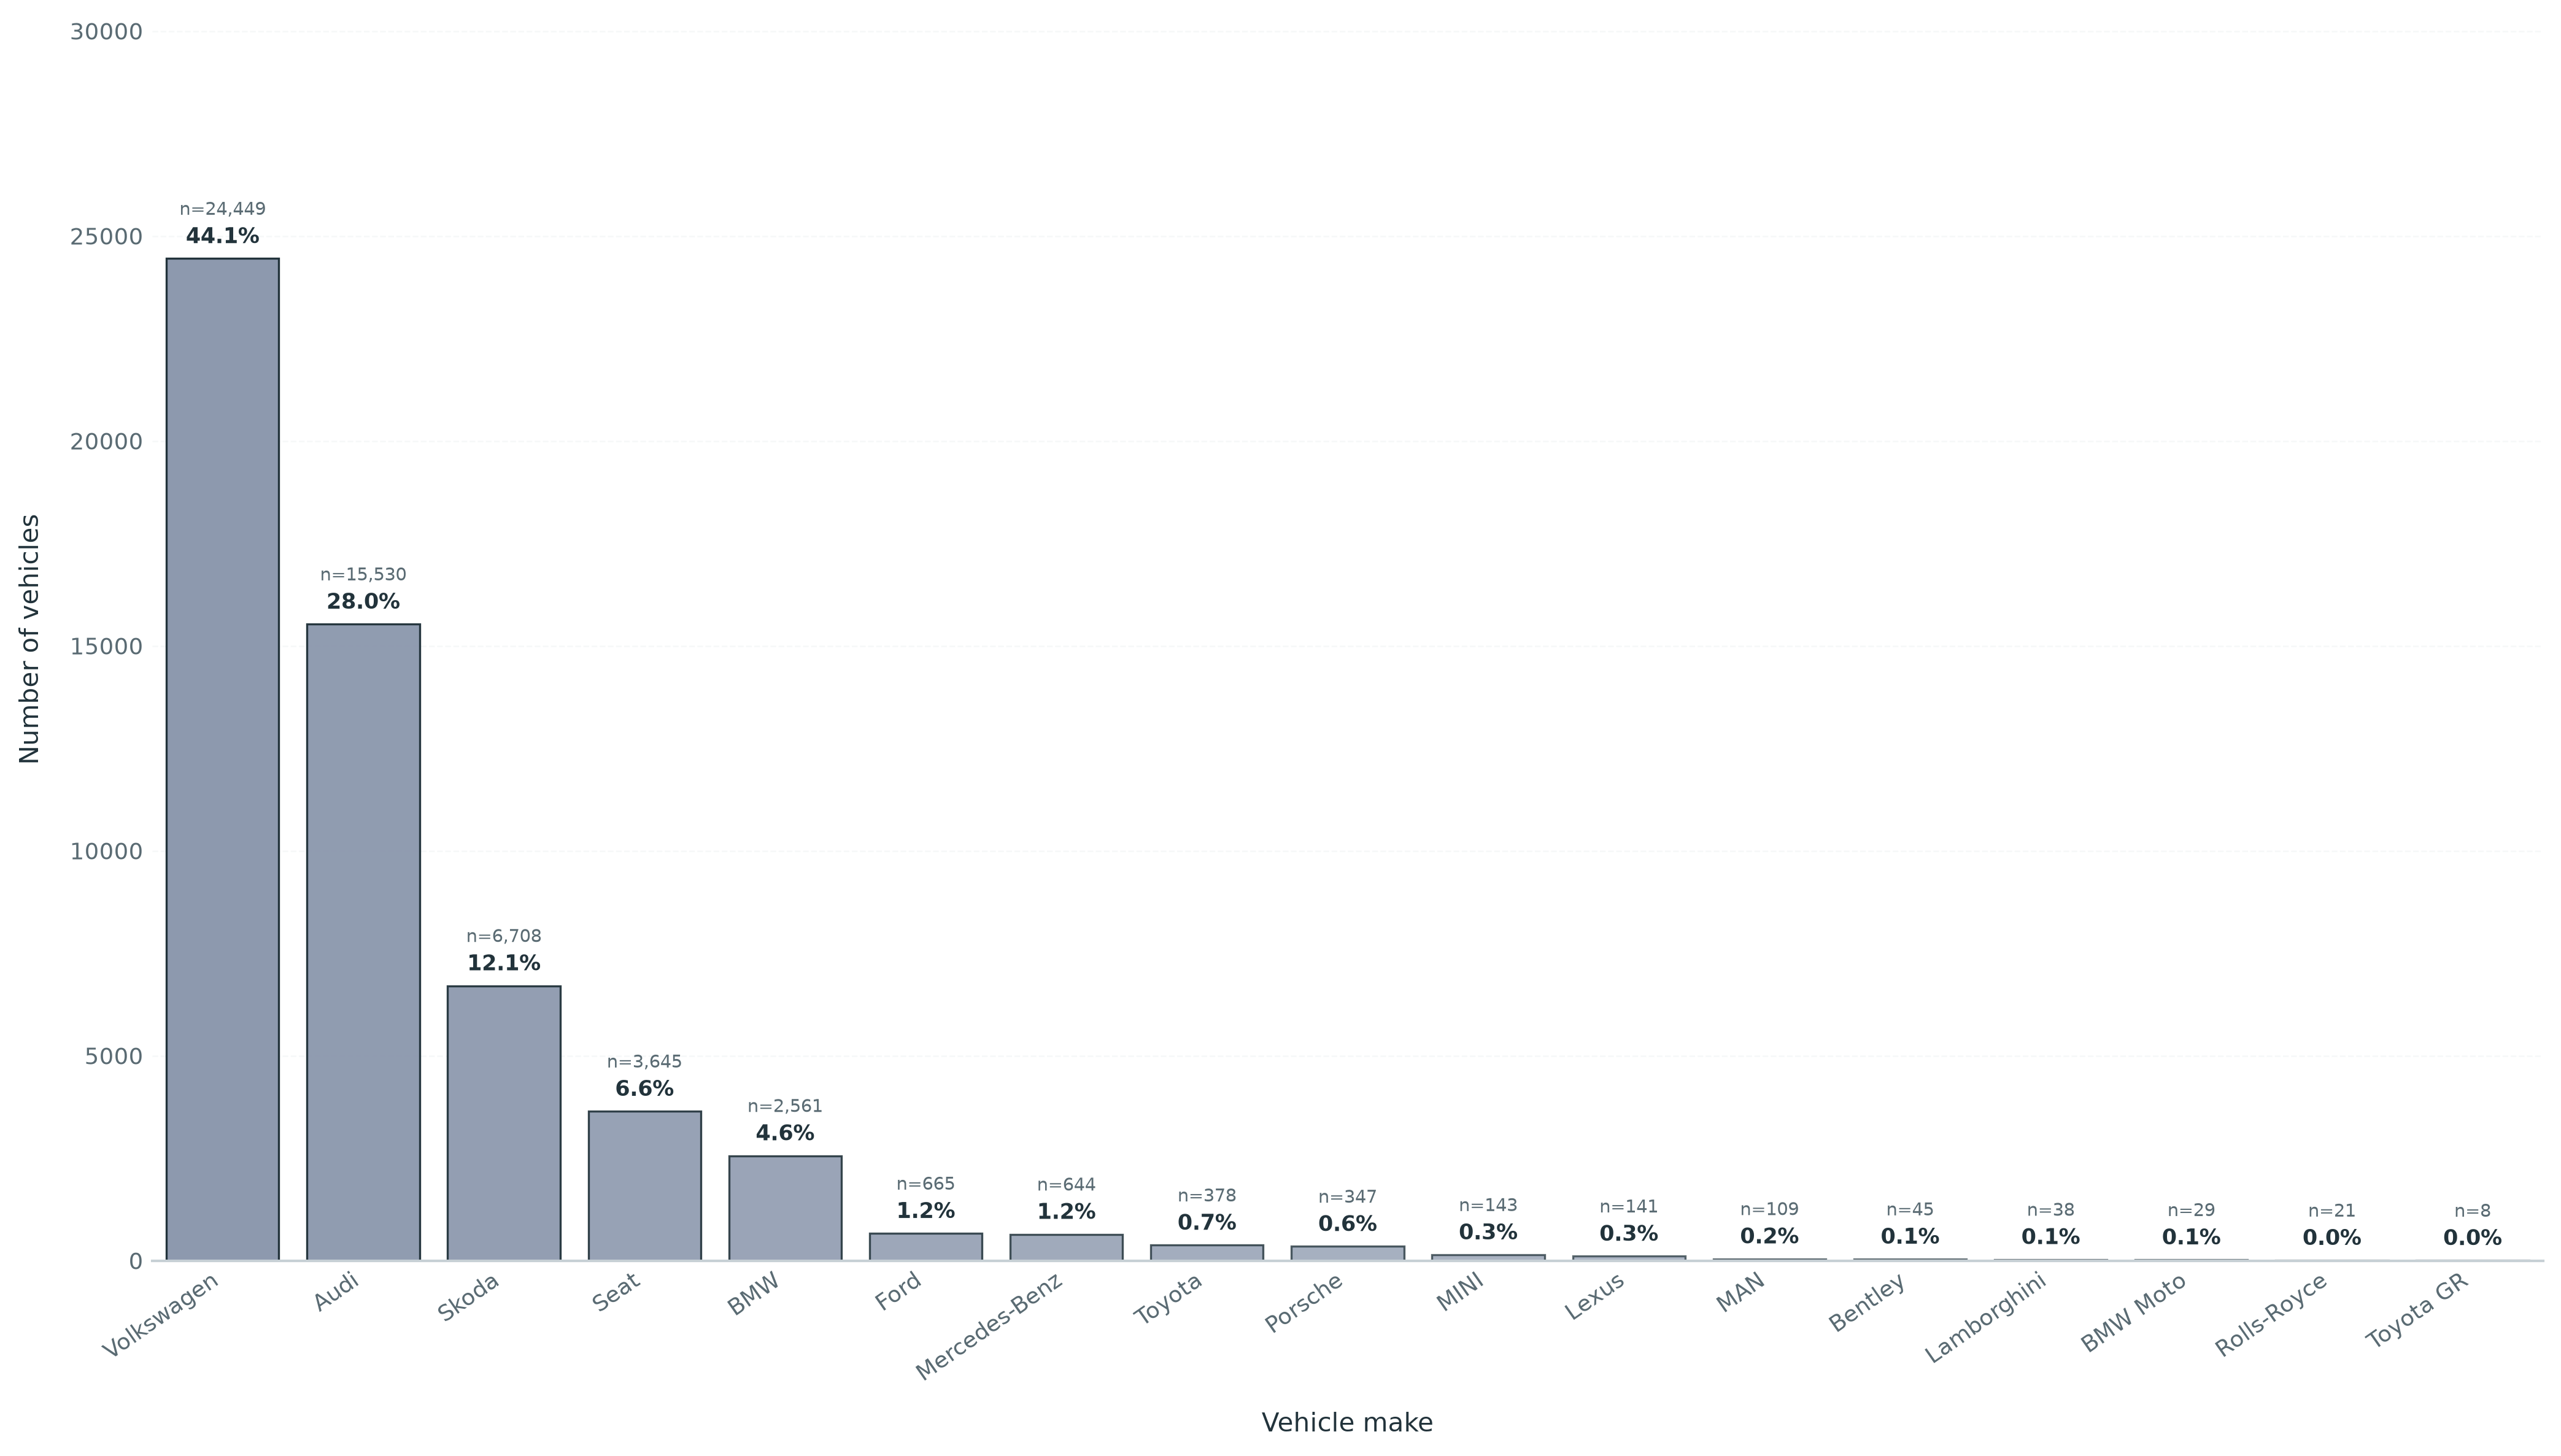

In [93]:
fig, ax = plt.subplots(figsize=(14, 8))

merged_all_v_plot = plotter.return_vehicle_make_distribution_plot(merged_all_raw, ax=ax)

plt.tight_layout()
fig.savefig(FIGURE_DIR / "06_vehicle_make_all_users.png", bbox_inches="tight")
plt.show()

## 9. Ties between users

Distribution of ties within the dataset after churn filters have been applied. Justifies
the use of tie-breaking equation for Cox PH


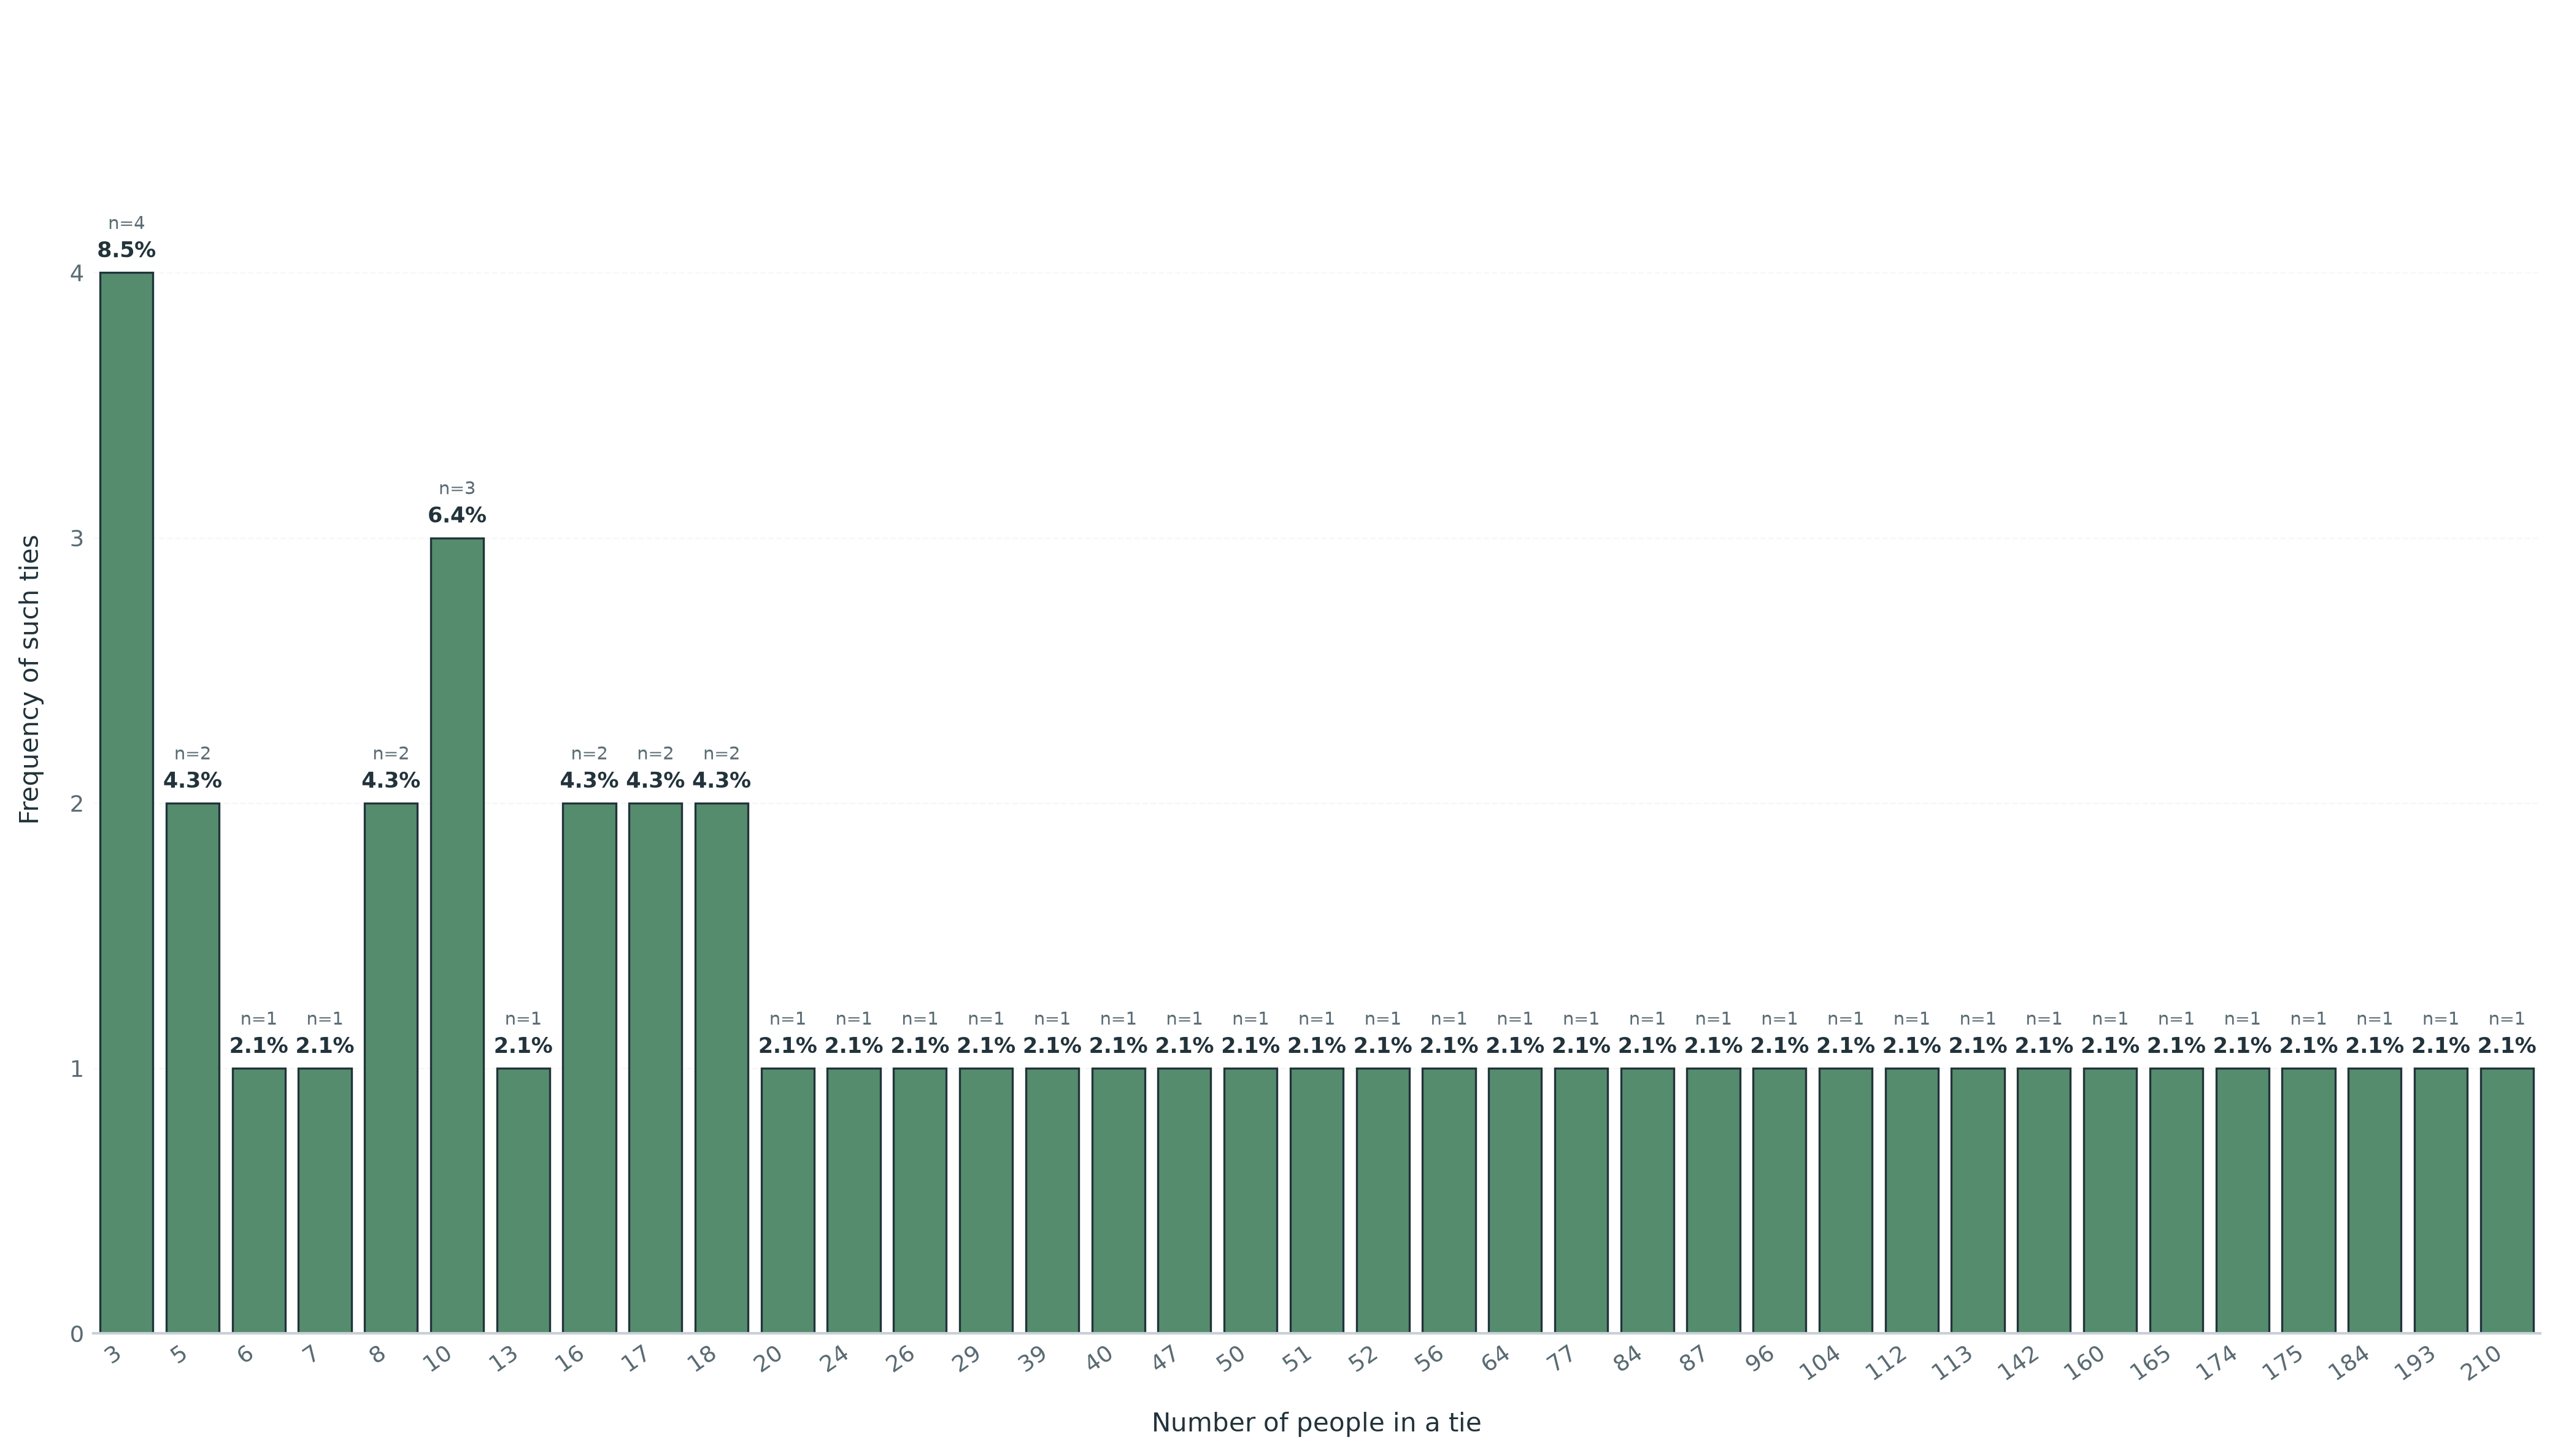

In [94]:
from src.constants import paths_to_files_and_folders as const
personal_features = pl.read_csv(PERSONAL_FEATURE_AGGREGATED)
fig, ax = plt.subplots(figsize=(14, 8))

dp = PlottingData()

dp.return_interval_ties_summary(personal_features,
                                ax=ax,
                                personal=True)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "07_interval_ties.png", bbox_inches="tight")
plt.show()

## 10. Churning, EPV and Censoring (Events Per Variable)

After applying churn filtering the number of variables is determined by how many events exist. Justifying a basic limit to how many variables can be derived 


In [95]:
print(f"Total user count (Personal): {personal_filtered['user_id'].unique().count()}")
print(f"Churning users (Personal): {personal_filtered['churn_triggered'].sum()}")
print(f"Churning users (Personal): {personal_filtered['churn_triggered'].sum() / personal_filtered['user_id'].unique().count() * 100:.2f}%")
print()

print(f"Total user count (Professional): {professional_filtered['user_id'].unique().count()}")
print(f"Churning users (Professional): {professional_filtered['churn_triggered'].sum()}")
print()


percentage_value = 0.64
# Personal
print(f"Personal - Safe side 30 EPV ({percentage_value*100}% Train): {personal_filtered['churn_triggered'].sum() * percentage_value / 30:.1f}")
print(f"Personal - Safe side 20 EPV ({percentage_value*100}% Train): {personal_filtered['churn_triggered'].sum() * percentage_value / 20:.1f}")
print()

# Professional
print(f"Professional - Safe side 30 EPV ({percentage_value*100}% Train): {professional_filtered['churn_triggered'].sum() * percentage_value / 30:.1f}")
print(f"Professional - Safe side 20 EPV ({percentage_value*100}% Train): {professional_filtered['churn_triggered'].sum() * percentage_value / 20:.1f}")

Total user count (Personal): 6000
Churning users (Personal): 2774
Churning users (Personal): 46.23%

Total user count (Professional): 514
Churning users (Professional): 254

Personal - Safe side 30 EPV (64.0% Train): 59.2
Personal - Safe side 20 EPV (64.0% Train): 88.8

Professional - Safe side 30 EPV (64.0% Train): 5.4
Professional - Safe side 20 EPV (64.0% Train): 8.1


## 11. Correlation of the final personal-user feature set

Correlation structure of the current 14-day feature dataset generated from the full raw export.


In [96]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [97]:
personal_features = pl.read_csv(PERSONAL_FEATURE_AGGREGATED)
print(f"Current feature set: {personal_features.shape[1]} columns, {personal_features.shape[0]:,} rows")


Current feature set: 34 columns, 124,783 rows


In [98]:
# Human-readable labels for the current feature set.
pretty_col = variables_and_groupings.pretty_new_features

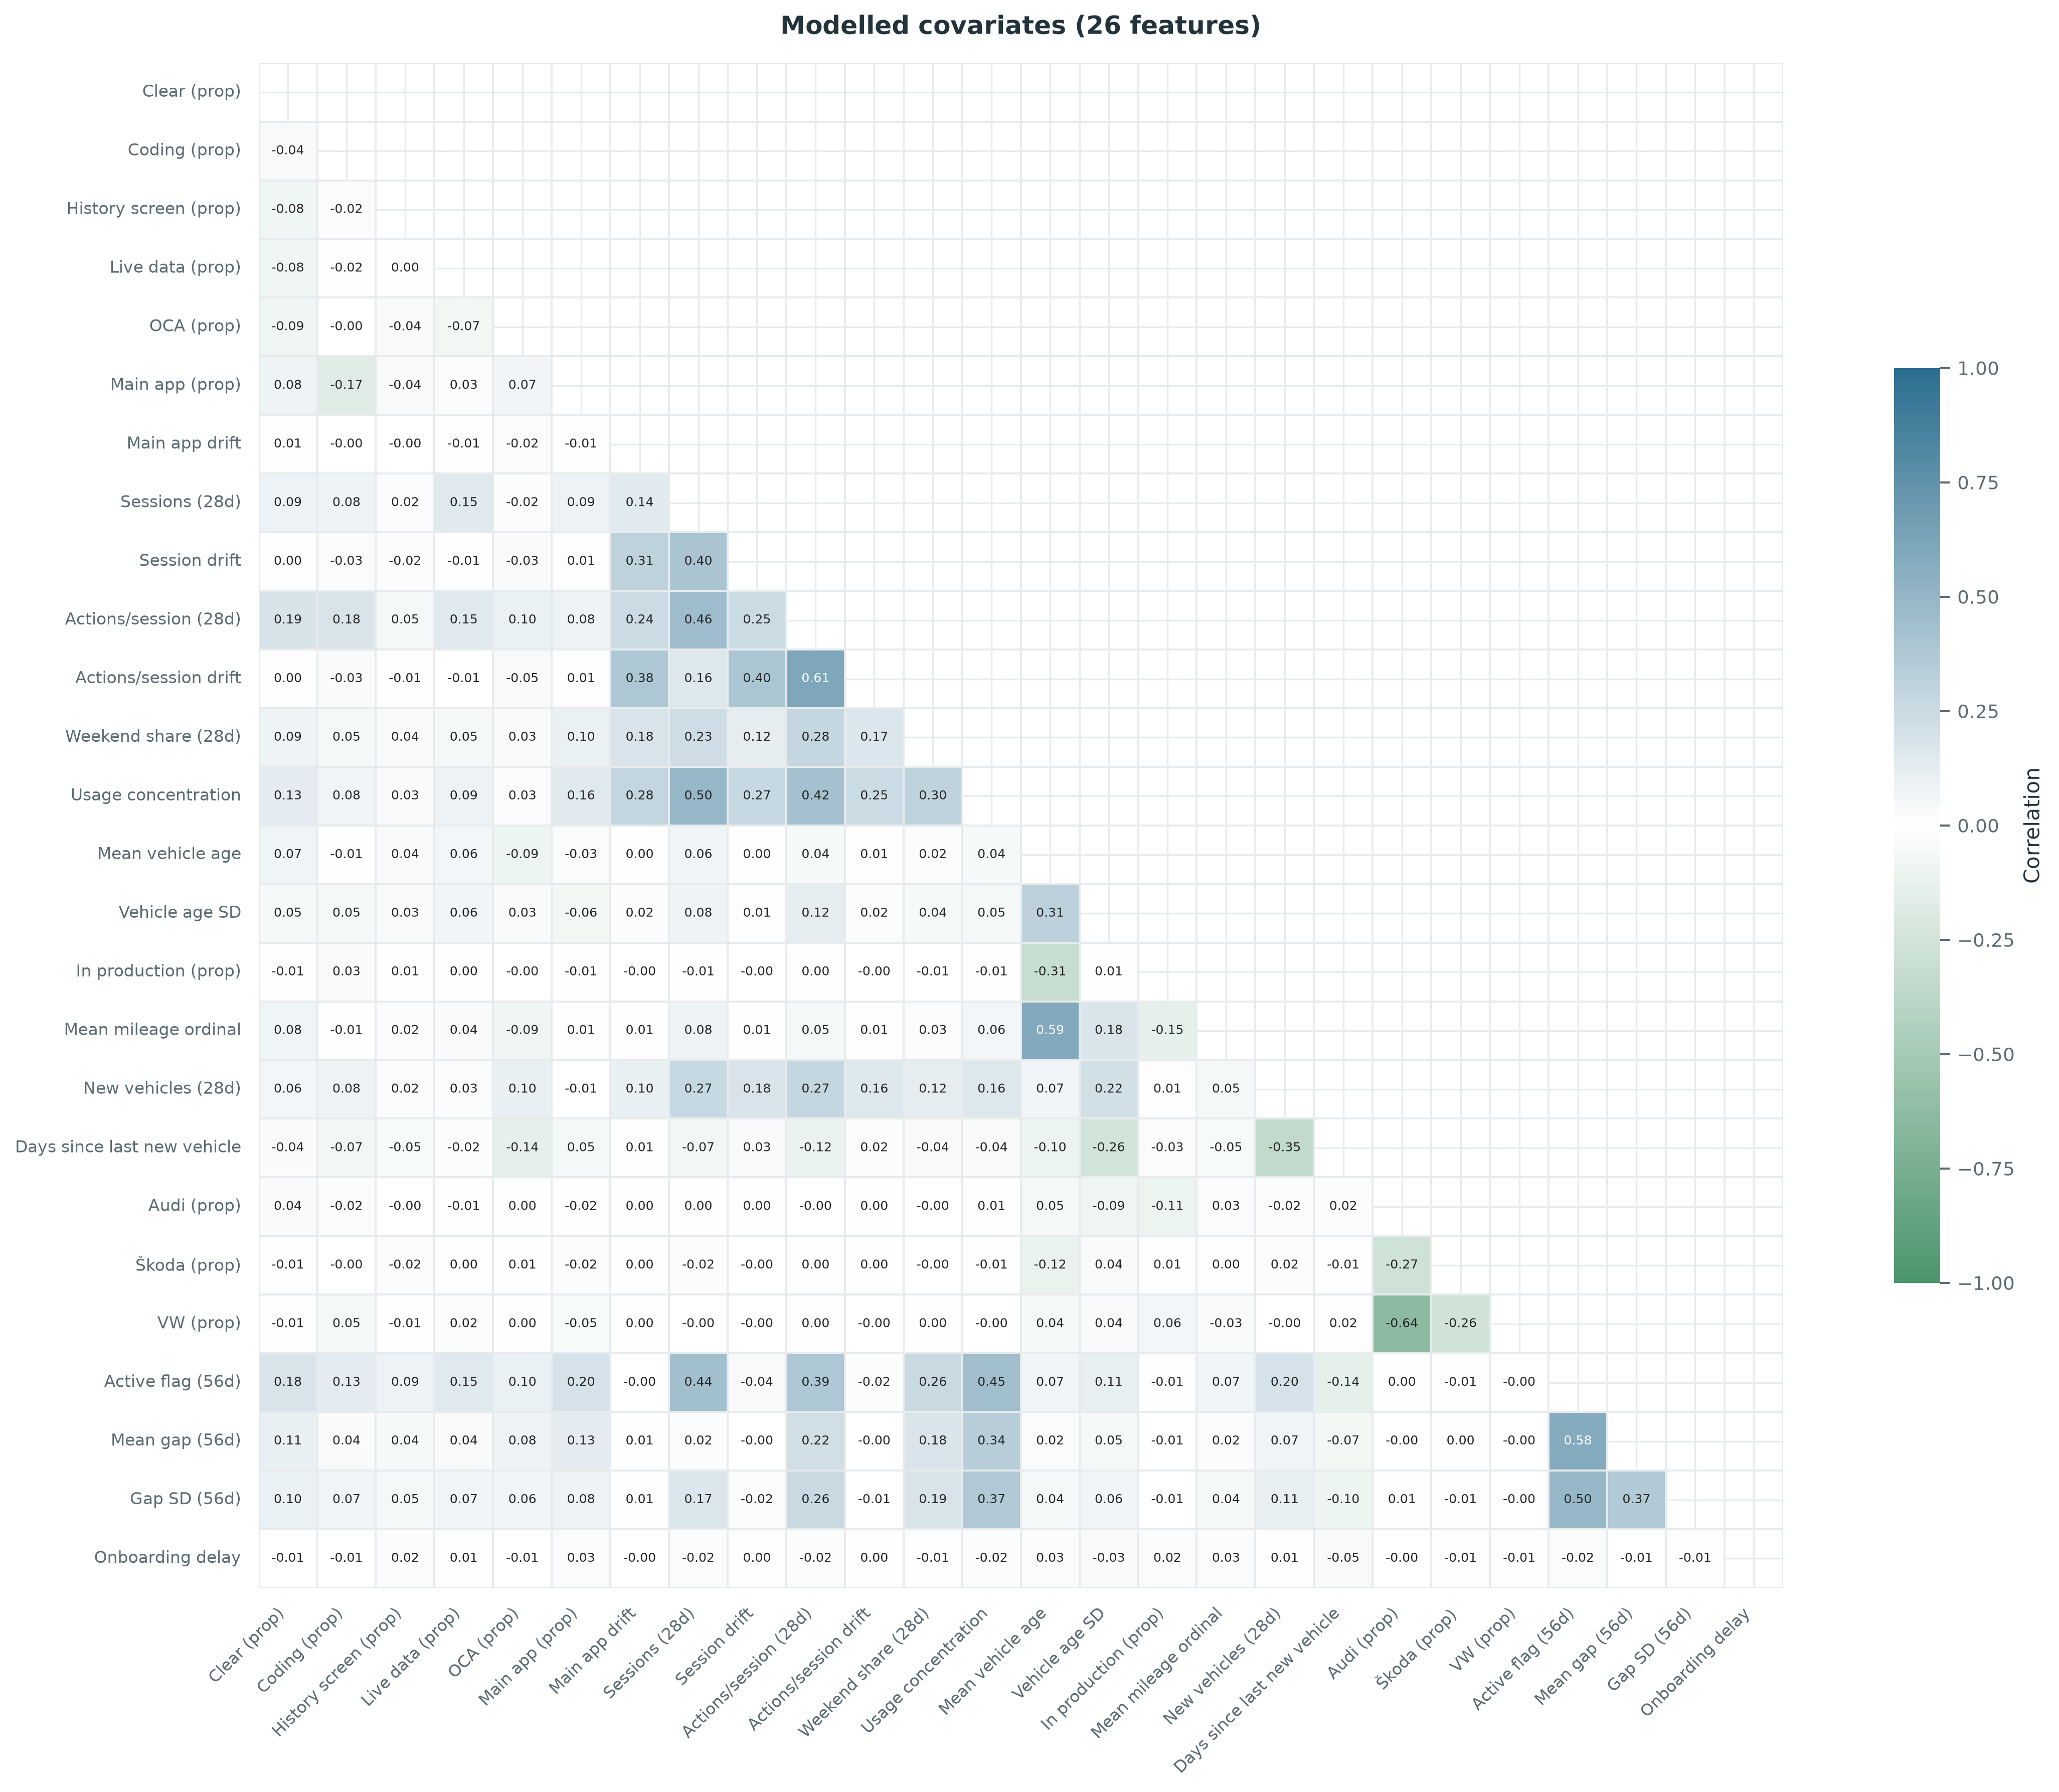

In [99]:
# Correlations are read on the covariates that actually enter the Cox fit, so the
# identification-driven exclusions (Section 'Excluded covariates') are dropped here too.
corr_drop = variables_and_groupings.COLUMS_TO_EXCLUDE + [
    "recency",
    "account_tenure_days",
    "CV_gap_0_56_days",
    "prop_scan_0_56",
]

fig, ax = plt.subplots(figsize=(16, 12))
plotter.return_correlation_plot(
    personal_features, pretty=pretty_col, ax=ax, cols_to_drop=corr_drop
)
ax.set_title(
    f"Modelled covariates ({personal_features.shape[1] - len(corr_drop)} features)",
    color="#22333B",
    fontweight="bold",
    pad=14,
)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "08_feature_correlation.png", bbox_inches="tight")
plt.show()

In [100]:
vif = summary.compute_vif(
    personal_features,
    pretty_col,
    variables_and_groupings.COLUMS_TO_EXCLUDE,
)
print("Current feature-set VIF (descending):")
with pd.option_context("display.max_rows", None, "display.width", 120):
    print(vif)

Current feature-set VIF (descending):
                        feature       VIF
0                       Recency  6.398498
1                  Gap CV (56d)  6.092434
2                  Gap SD (56d)  4.095550
3             Active flag (56d)  3.814264
4                   Scan (prop)  3.688126
5         Actions/session (28d)  3.010993
6                Sessions (28d)  2.895561
7                   Audi (prop)  2.672817
8                     VW (prop)  2.653192
9         Actions/session drift  2.470168
10               Mean gap (56d)  2.406487
11          Usage concentration  2.317772
12             Mean vehicle age  1.904187
13  Days since last new vehicle  1.800462
14             Live data (prop)  1.772484
15               Account tenure  1.728657
16                Session drift  1.724580
17                   OCA (prop)  1.717927
18                 Škoda (prop)  1.679220
19         Mean mileage ordinal  1.565662
20               Vehicle age SD  1.472814
21                Coding (prop)  1.467

## 12. Separation assessment (PERSONAL)


In [101]:
personal_features.group_by("churn_triggered_adjusted").mean()

churn_triggered_adjusted,user_id,interval_start,interval_end,prop_clear_0_56,prop_coding_0_56,prop_history_screen_0_56,prop_live_data_0_56,prop_oca_0_56,prop_scan_0_56,prop_main_0_56,prop_main_drift_0_28_vs_28_56,n_sessions_0_28_days,sessions_intensity_drift_0_28_vs_28_56_days,actions_per_session_0_28_days,actions_per_session_intensity_drift_0_28_vs_28_56_days,recency,weekend_share_0_28_days,usage_concentration,vehicle_mean_age_overall,vehicle_age_sd_overall,prop_in_prod,vehicle_mean_mileage_ordinal,n_new_vehicles_0_28_days,days_since_last_new_vehicle,overall_prop_vehicle_make_audi,overall_prop_vehicle_make_skoda,overall_prop_vehicle_make_volkswagen,active_flag_0_56_days,CV_gap_0_56_days,mean_gap_0_56_days,sd_gap_0_56_days,account_tenure_days,onboarding_delay_days
bool,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
false,null,255.142309,269.142309,0.076253,0.036855,0.037909,0.065496,0.07388,0.505721,0.385242,-0.007252,1.858797,-0.168938,1.320255,-0.115963,30.35931,0.168128,0.38935,11.781059,2.518923,0.043681,3.4345,0.185757,143.970617,0.340605,0.099454,0.426143,0.609578,0.401424,6.117508,3.211921,289.436312,20.294003
true,null,185.391492,199.391492,0.060077,0.026639,0.030736,0.052746,0.071271,0.413857,0.363007,0.007521,0.994593,-0.089762,0.986053,-0.076514,45.292718,0.125445,0.295591,11.302279,1.907977,0.054393,3.124889,0.137347,127.706921,0.336364,0.089302,0.434566,0.426099,0.243691,4.835952,2.167629,222.923576,23.532084


In [102]:
personal_features.drop(["user_id", "interval_start", "interval_end"])

prop_clear_0_56,prop_coding_0_56,prop_history_screen_0_56,prop_live_data_0_56,prop_oca_0_56,prop_scan_0_56,prop_main_0_56,prop_main_drift_0_28_vs_28_56,n_sessions_0_28_days,sessions_intensity_drift_0_28_vs_28_56_days,actions_per_session_0_28_days,actions_per_session_intensity_drift_0_28_vs_28_56_days,recency,weekend_share_0_28_days,usage_concentration,vehicle_mean_age_overall,vehicle_age_sd_overall,prop_in_prod,vehicle_mean_mileage_ordinal,n_new_vehicles_0_28_days,days_since_last_new_vehicle,overall_prop_vehicle_make_audi,overall_prop_vehicle_make_skoda,overall_prop_vehicle_make_volkswagen,churn_triggered_adjusted,active_flag_0_56_days,CV_gap_0_56_days,mean_gap_0_56_days,sd_gap_0_56_days,account_tenure_days,onboarding_delay_days
f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,i64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,bool,bool,f64,f64,f64,i64,i64
0.0,0.5,0.125,0.0,0.1875,0.1875,0.0,0.0,1,-4,2.0,-0.8,25,1.0,0.0,6.0,1.0,0.5,2.5,1,25,0.0,1.0,0.0,false,true,1.159721,6.2,7.190271,56,0
0.0,0.5,0.1,0.0,0.2,0.2,0.0,0.0,2,0,3.0,1.0,4,0.5,1.0,6.0,1.0,0.5,2.5,0,39,0.0,1.0,0.0,false,true,1.213098,14.333333,17.387735,70,0
0.0,0.625,0.0,0.0,0.25,0.125,0.0,0.0,2,1,3.0,1.0,18,0.5,0.0,6.0,1.0,0.5,2.5,0,53,0.0,1.0,0.0,false,true,1.333401,17.5,23.334524,84,0
0.0,0.666667,0.0,0.0,0.166667,0.166667,0.0,0.0,0,-2,0.0,-3.0,32,0.0,0.0,6.0,1.0,0.5,2.5,0,67,0.0,1.0,0.0,false,true,0.0,1.0,0.0,98,0
0.0,0.666667,0.0,0.0,0.166667,0.166667,0.0,0.0,0,-2,0.0,-3.0,46,0.0,0.0,6.0,1.0,0.5,2.5,0,81,0.0,1.0,0.0,false,true,0.0,1.0,0.0,112,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,0.0,0.0,0.0,0.0,1.0,0.666667,-0.666667,0,-2,0.0,-1.5,41,0.0,0.0,10.333333,5.217492,0.0,5.0,0,41,0.0,0.333333,0.5,false,true,0.0,12.0,0.0,197,15
0.0,0.0,0.0,0.0,0.0,1.0,0.5,-0.5,0,-1,0.0,-2.0,55,0.0,0.0,10.333333,5.217492,0.0,5.0,0,55,0.0,0.333333,0.5,false,false,0.0,0.0,0.0,211,15
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,69,0.0,0.0,10.333333,5.217492,0.0,5.0,0,69,0.0,0.333333,0.5,false,false,0.0,0.0,0.0,225,15


In [103]:
personal_features["churn_triggered_adjusted"].sum()

2774

In [104]:
personal_features["user_id"].n_unique()



6000